In [1]:
import pandas as pd
import numpy as np

df= pd.read_csv('googleplaystore.csv')
print("shape:",df.shape)
print("\ncolumns:", df.columns.tolist())
df.head()

shape: (10841, 13)

columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [7]:
df = df.drop_duplicates(subset='App')
print("Duplicates after dropping :", df.shape)

df = df[df['Category'] != '1.9']
df = df.dropna(subset=['Rating'])


df['Installs'] = df['Installs'].astype(str).str.replace('+', '').str.replace(',', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')  
df = df.dropna(subset=['Installs'])  
df['Installs'] = df['Installs'].astype(int)


df['Price'] = df['Price'].astype(str).str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'] = df['Price'].fillna(0)  


def convert_size(size_str):
    if 'M' in str(size_str):
        return float(str(size_str).replace('M', ''))
    elif 'k' in str(size_str):
        return float(str(size_str).replace('k', '')) / 1000
    else:
        return np.nan

df['Size'] = df['Size'].apply(convert_size)

#
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce').fillna(0).astype(int)

print("shape after cleaning:", df.shape)
print("Data cleaning completed ")
df.info()

Duplicates after dropping : (8196, 14)
shape after cleaning: (8196, 14)
Data cleaning completed 
<class 'pandas.DataFrame'>
Index: 8196 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8196 non-null   str    
 1   Category        8196 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         8196 non-null   int64  
 4   Size            0 non-null      float64
 5   Installs        8196 non-null   int64  
 6   Type            8196 non-null   str    
 7   Price           8196 non-null   float64
 8   Content Rating  8196 non-null   str    
 9   Genres          8196 non-null   str    
 10  Last Updated    8196 non-null   str    
 11  Current Ver     8192 non-null   str    
 12  Android Ver     8194 non-null   str    
 13  price           8196 non-null   float64
dtypes: float64(4), int64(2), str(8)
memory usage: 960.5 KB


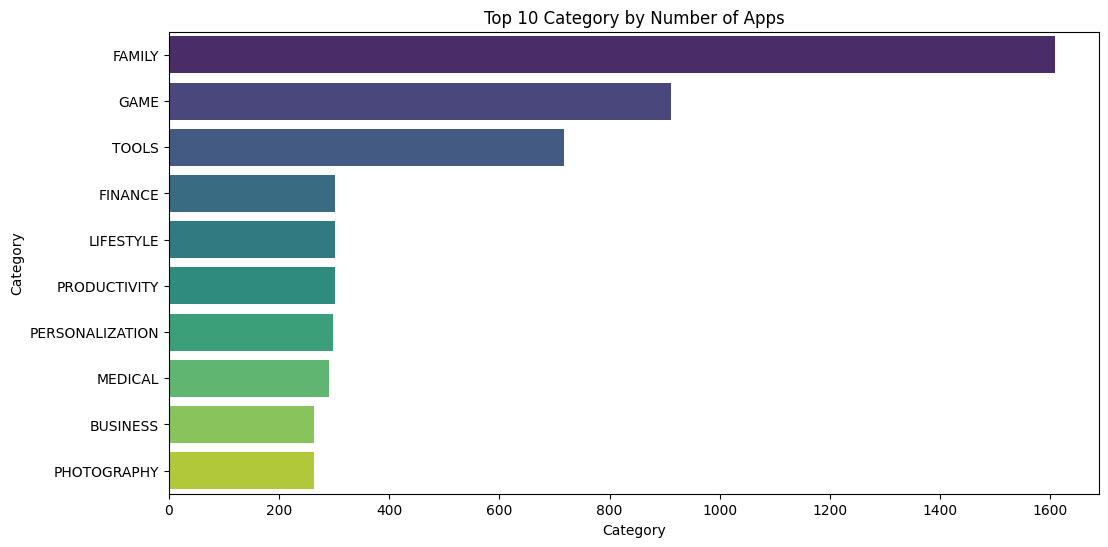

Insight:FAMILY and GAME are the most popular categories in the Google Play Store


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
top_cat=df['Category'].value_counts().head(10)
sns.barplot(x=top_cat.values, y=top_cat.index,hue=top_cat.index, palette='viridis', legend=False)
plt.title('Top 10 Category by Number of Apps')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.ylabel('Category')
plt.show()
print("Insight:FAMILY and GAME are the most popular categories in the Google Play Store")



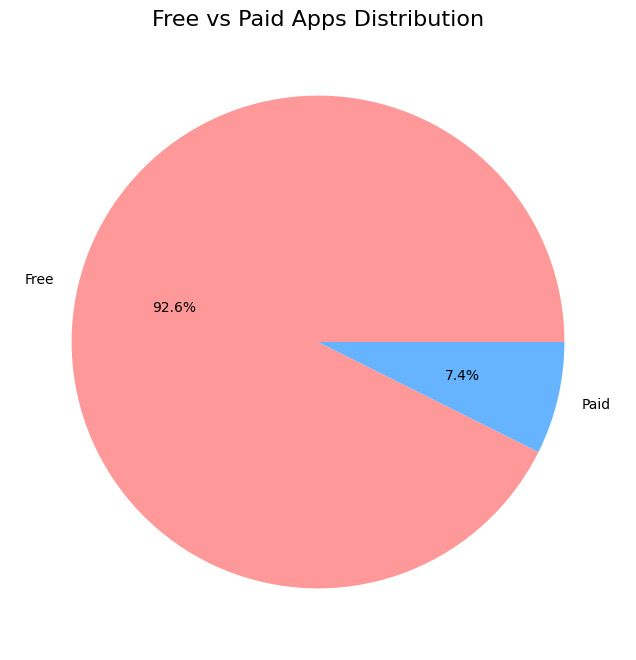

Insight:  92.6  % of apps are free


In [10]:
plt.figure(figsize=(8,8))
type_count=df['Type'].value_counts()
plt.pie(type_count, labels=type_count.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Free vs Paid Apps Distribution', fontsize=16)
plt.show()
print("Insight: ", round(df['Type'].value_counts(normalize=True)['Free']*100, 1), " % of apps are free") 

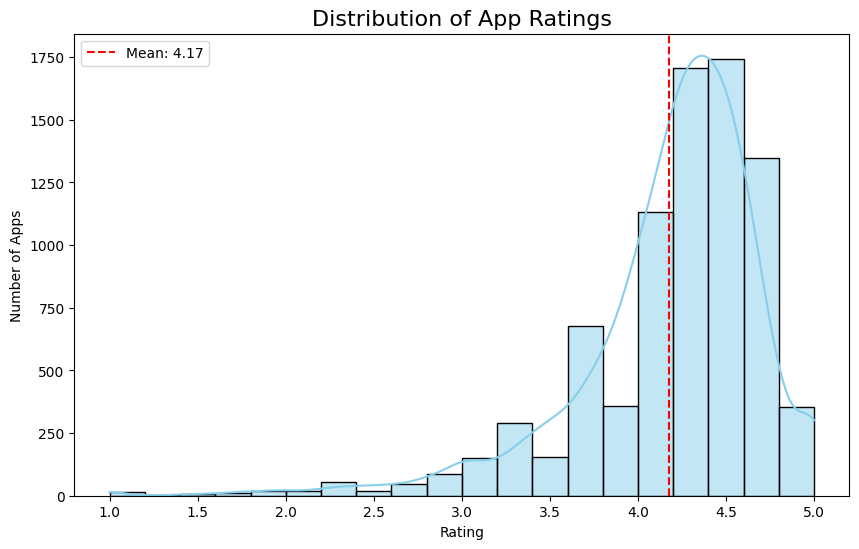

Insight: The average rating of apps is {df['Rating'].mean():.2f}, with most apps having ratings between 4 and 5


In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of App Ratings', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.axvline(df['Rating'].mean(), color='red', linestyle='dashed', label=f"Mean: {df['Rating'].mean():.2f}")       
plt.legend()
plt.show()

print("Insight: The average rating of apps is {df['Rating'].mean():.2f}, with most apps having ratings between 4 and 5")

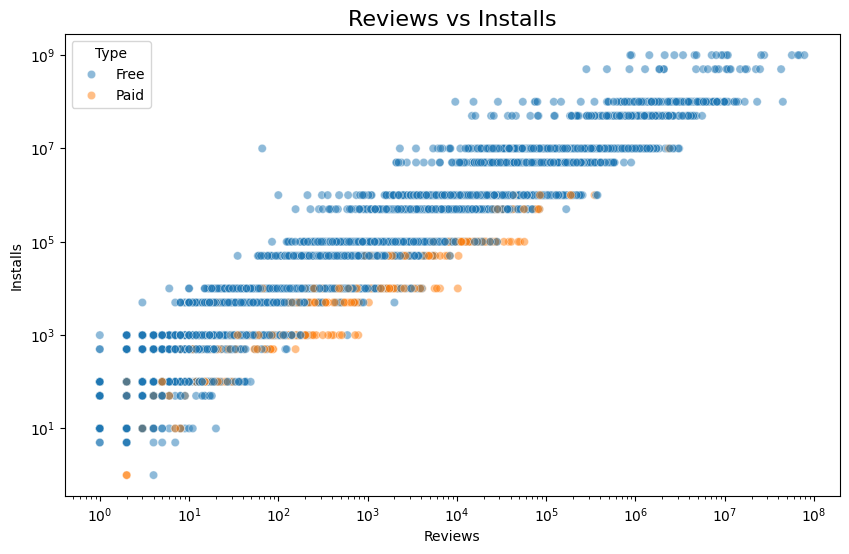

Insight: more reviews generally lead to more installs, indicating a positive correlation between reviews and installs


In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Reviews', y='Installs', data=df, alpha=0.5, hue='Type')
plt.title('Reviews vs Installs', fontsize=16)
plt.xscale('log')
plt.yscale('log')
plt.show()
print("Insight: more reviews generally lead to more installs, indicating a positive correlation between reviews and installs")  

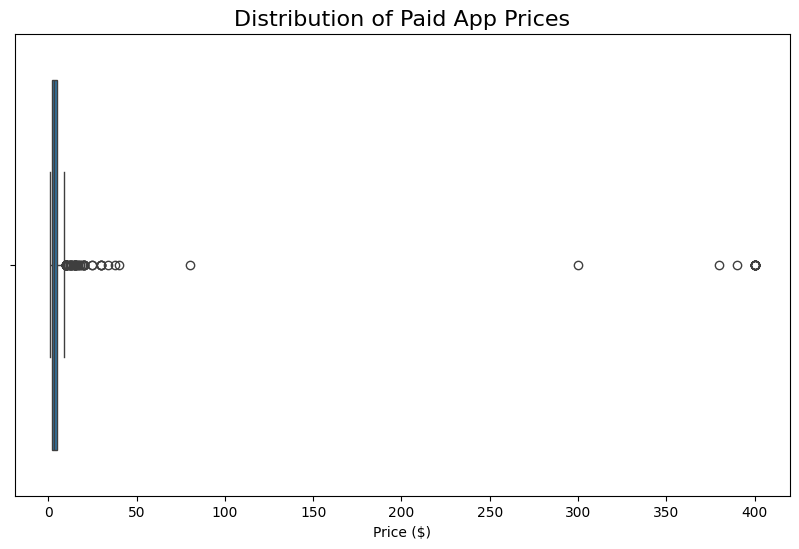

Insight: Paid apps 75% of paid apps are priced below $5, outliers $400 also exist


In [16]:
plt.figure(figsize=(10, 6))
paid_apps = df[df['Type'] == 'Paid']
sns.boxplot(x=paid_apps['Price'])
plt.title('Distribution of Paid App Prices', fontsize=16)
plt.xlabel('Price ($)')
plt.show()

print("Insight: Paid apps 75% of paid apps are priced below $5, outliers $400 also exist")